# Módulo 1 · Explorando una serie temporal con Python

Curso: **Series Temporales con R y Python** (Frogames Formación).

Este notebook es el código de acompañamiento de la lección `01-introduccion-a-series-de-tiempo/02-explorando-una-serie-con-python` — ábrelo mientras lees la lección en el navegador y ejecuta cada celda tú mismo.

Trabajamos con el precio de cierre diario del **S&P 500** (ticker `^GSPC`), 2015-01-02 a 2026-09-15 (2.942 observaciones). El CSV ya descargado está en esta misma carpeta (`sp500_close_2015_2026.csv`) para que no dependas de la red — pero la celda siguiente es exactamente cómo se generó, por si quieres repetirlo con datos más recientes.

In [1]:
# Opcional: así se generó sp500_close_2015_2026.csv. No hace falta ejecutar esta celda
# para seguir el resto del notebook (el CSV ya está en esta carpeta).

import yfinance as yf

df_live = yf.download("^GSPC", start="2015-01-01", end="2026-09-16",
                       interval="1d", threads=False)  # threads=False: ver AUDITORIA-TECNICA.md
# df_live[["Close"]].rename(columns={"Close": "close"}).to_csv("sp500_close_2015_2026.csv", index_label="date")

[                       0%                       ]

[*********************100%***********************]  1 of 1 completed

## Carga y primer vistazo

`parse_dates` + `index_col` es el paso que convierte una columna de texto en un índice temporal real.

In [2]:
import pandas as pd

df = pd.read_csv("sp500_close_2015_2026.csv", parse_dates=["date"], index_col="date")
df.head()

,close
date,
2015-01-02,2058.199951
2015-01-05,2020.579956
2015-01-06,2002.609985
2015-01-07,2025.900024
2015-01-08,2062.139893


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2942 entries, 2015-01-02 to 2026-09-15
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   2942 non-null   float64
dtypes: float64(1)
memory usage: 46.0 KB


## Huecos: festivo de mercado, no dato perdido

Si comparas el índice real contra un calendario laboral completo, faltan días — pero no son `NaN`.

In [4]:
calendario = pd.date_range(df.index.min(), df.index.max(), freq="B")
huecos = calendario.difference(df.index)

print("días laborables esperados:", len(calendario))
print("días con dato real:", len(df))
print("días laborables sin dato:", len(huecos))
print("nulos reales (NaN):", df["close"].isna().sum())

días laborables esperados: 3053
días con dato real: 2942
días laborables sin dato: 111
nulos reales (NaN): 0


## El gráfico de la serie completa

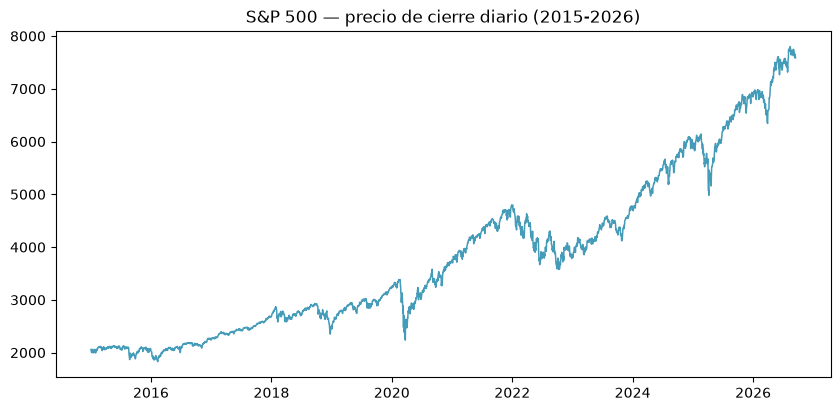

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(df.index, df["close"], color="#449cb9", linewidth=1.1)
ax.set_title("S&P 500 — precio de cierre diario (2015-2026)")
plt.show()

## Retornos diarios y QQ-plot

A partir de aquí trabajamos con **retornos**, no con precios: los precios tienen tendencia (no son estacionarios, formalizado en el Módulo 3).

In [6]:
returns = df["close"].pct_change().dropna() * 100  # en %
returns.describe()

count    2941.000000
mean        0.050573
std         1.112830
min       -11.984055
25%        -0.380124
50%         0.067620
75%         0.580029
max         9.515388
Name: close, dtype: float64

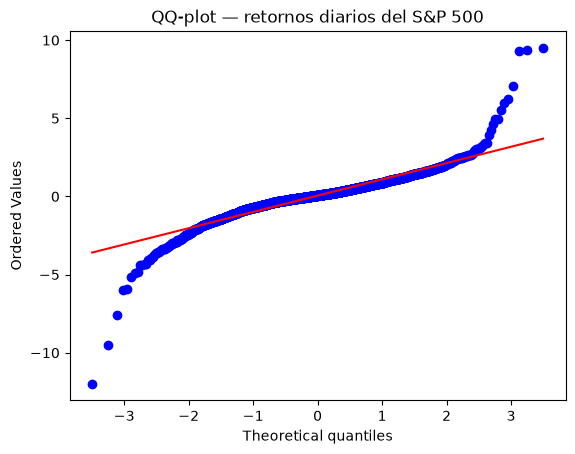

skew: -0.3566221171512145
curtosis (exceso): 15.049318225427948
Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.8777640338584212), pvalue=np.float64(3.1218698145548262e-43))


In [7]:
from scipy import stats

stats.probplot(returns, dist="norm", plot=plt)
plt.title("QQ-plot — retornos diarios del S&P 500")
plt.show()

print("skew:", returns.skew())
print("curtosis (exceso):", returns.kurtosis())
print("Shapiro-Wilk:", stats.shapiro(returns))

**Cómo leer esto**: en el centro los puntos siguen la recta de la normal teórica; en ambos extremos se separan — la firma visual de **colas pesadas** (más días extremos de los que predice una normal). Coincide con la curtosis de exceso (~15, muy por encima de 0) y con el rechazo de normalidad del test de Shapiro-Wilk. Es el primer *hecho estilizado* de series financieras del curso — reaparece en los módulos ARCH y GARCH.

**Entregable**: reproduce estas celdas y, en tus propias notas, contesta: si alguien dice "los retornos son perfectamente normales" mirando el QQ-plot, ¿en qué zona exacta del gráfico está la evidencia de que no lo son?